In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import matplotlib.pyplot as plt
from aicsimageio import AICSImage
import platform
from scipy.ndimage import gaussian_filter
from joblib import Parallel, delayed
import pickle

system = platform.system()

if system == 'Linux':
    home = '/home/gerard/'
elif system == 'Darwin':
    home = '/Users/gerard/'
elif system == "Windows":
    home = 'C:/Users/cviko/'



try:
    sys.path.append(os.path.abspath(os.path.join(os.pardir, 'src')))
    from data_processing import *
    from utils import *
    from plotter import *
    from colocalization import *
except:
    path2add = home + 'analysis/confocal/src'
    sys.path.append(path2add)
    from data_processing import *
    from utils import *
    from plotter import *
    from colocalization import *


home = home + 'data/confocal/'


In [2]:
date = '2026_06_05'
user = 'Carmina'
info = describe_acquisition( home + date + '_' + user + '/Project.lif')


══════════════════════════════════════════════════════════════
Scene 0: dec02_5x_brain1alphaprime_L
══════════════════════════════════════════════════════════════
  Objective  : HC PL APO CS2    63x/1.40 OIL
  NA / n     : 1.4 / 1.518
  Voxel size : XY = 0.0226 µm/px  |  Z = 0.1307 µm/step
  Shape      : 61 × 512 × 512  (Z × Y × X)

  ────────────────────────────────────── Acquisition sequences
  Seq 1  laser(s): 488 nm + 638 nm  [simultaneous]
         pinhole  : 20.00 µm  (0.209 AU)
         det ch1  501–610 nm  Leica/ALEXA 488         em = 519 nm
         det ch2  643–788 nm  Leica/Cy5               em = 670 nm
  Seq 2  laser(s): 552 nm
         pinhole  : 20.00 µm  (0.209 AU)
         det ch2  557–761 nm  Leica/ALEXA 546         em = 573 nm

  ────────────────────────────────────── Image channels (0-indexed)
  ch0  Leica/ALEXA 488         em=519 nm  σ_xy=3.45px (0.078µm) [✓]  σ_z=2.03px [✓]  → 3D
  ch1  Leica/Cy5               em=670 nm  σ_xy=4.45px (0.101µm) [✓]  σ_z=2.62px [✓]  

In [5]:
loader2(date,user,False, False)

/home/gerard/data/confocal/2026_06_05_Carmina
Number of series: 10
series 0: shape = (1, 3, 61, 512, 512)
series 1: shape = (1, 3, 134, 512, 512)
series 2: shape = (1, 3, 121, 512, 512)
series 3: shape = (1, 3, 88, 512, 512)
series 4: shape = (1, 3, 174, 512, 512)
series 5: shape = (1, 3, 121, 512, 512)
series 6: shape = (1, 3, 127, 512, 512)
series 7: shape = (1, 3, 197, 512, 512)
series 8: shape = (1, 3, 101, 512, 512)
series 9: shape = (1, 3, 94, 512, 512)


### DECONVOLUTION :

In [3]:


path_data = date + '_' + user + '/Project.lif'
path_data_all = home + path_data #os.path.join(hom

print(path_data_all)
img = AICSImage(path_data_all)
# print(len(img.scenes))
# print(img.scenes[0])



/home/gerard/data/confocal/2026_06_05_Carmina/Project.lif


#### serial version 

In [16]:



scenes = list(range(len(info.keys())))
#scenes = [0,1,2,3,4]
flagged2d_gaussian_lucy = []
flagged2d_estimate_blind_iter2 = []
#flagged2d_estimate_blind_iter4 =[]
flagged2d_estimate_blind_iter6 =[]
flagged2d_estimate_blind_iter20 =[]
#flagged2d_estimate_tv2 = []




## DESIRED NUMBER OF ITERATIONS:
iterations = [
      #      1,        
            2,
            # #3,
            #4,
            # 5,
            #6,
            # # 7, 
            # 10, 
            # 15,
            # 20,
            #20result[bg].std() / original[bg].std()
            ]

for scene in scenes:
    img.set_scene(img.scenes[scene])
    channels = list(range(len(info[list(info.keys())[scene]]['image_channels'])))
    for channel in channels:   
        stack = img.get_image_data("ZYX", T=0, C=channel)
        for num_iter in iterations:
            print(f'--------------> iteration {num_iter} for scene {scene} channel {channel}')
            
            result, sigma_xy_px = deconvolve(stack, path_data_all, channel=channel, scene=scene, num_iter=num_iter, forced2d = True)
            flagged = analyze_deconvolution_results(result, stack)
            flagged2d_gaussian_lucy.append(flagged)
            
            # result, sigma_xy_px = deconvolve(stack, path_data_all, channel=channel, scene=scene, num_iter=num_iter,  psf_model='gibson-lanni', forced2d = True)
            # flagged = analyze_deconvolution_results(result, stack)
            # flagged2d_gibson_lucy.append(flagged)
            
            #algorithm='unsupervised_wiener'
            
            result, sigma_xy_px = deconvolve(stack, path_data_all, channel=channel, scene=scene, num_iter=num_iter,  psf_model='estimate', forced2d = True, algorithm='blind_richardson_lucy')
            flagged = analyze_deconvolution_results(result, stack)
            flagged2d_estimate_blind_iter2.append(flagged)
            
            
            result, sigma_xy_px = deconvolve(stack, path_data_all, channel=channel, scene=scene, num_iter=6,  psf_model='estimate', forced2d = True, algorithm='blind_richardson_lucy')
            flagged = analyze_deconvolution_results(result, stack)
            flagged2d_estimate_blind_iter6.append(flagged)
             
            result, sigma_xy_px = deconvolve(stack, path_data_all, channel=channel, scene=scene, num_iter=20,  psf_model='estimate', forced2d = True, algorithm='blind_richardson_lucy')
            flagged = analyze_deconvolution_results(result, stack)
            flagged2d_estimate_blind_iter20.append(flagged)           

            
            # result, sigma_xy_px = deconvolve(stack, path_data_all, channel=channel, scene=scene, num_iter=num_iter,  psf_model='estimate', forced2d = True, algorithm='blind_richardson_lucy')
            # flagged = analyze_deconvolution_results(result, stack)
            # flagged2d_estimate_blind.append(flagged)
            
            # result, sigma_xy_px = deconvolve(stack, path_data_all, channel=channel, scene=scene, num_iter=num_iter,  psf_model='gibson-lanni', forced2d = True, algorithm='unsupervised_wiener')
            # flagged = analyze_deconvolution_results(result, stack)
            # flagged2d_gibson_wiener.append(flagged)
            
            # result, sigma_xy_px = deconvolve(stack, path_data_all, channel=channel, scene=scene, num_iter=num_iter, forced2d = True)
            # flagged = analyze_deconvolution_results(result, stack)
            # flagged2d.append(flagged)
            

--------------> iteration 2 for scene 0 channel 0
0.209 <------------------ pinhole
Applying pinhole factor 0.768 to PSF σ values: σ_xy 3.45 px → 2.65 px, σ_z 2.03 px → 1.56 px
PSF (ch0, gaussian): λ=519 nm | σ_xy=0.060 µm (2.65 px) | σ_z=0.204 µm (1.56 px) → 2D-per-frame (σ_z=1.56 px, FORCED)
2026_06_05_s0_ch0_deconv2d_iter_2.tif
0.131 of inspected frames flagged
0.209 <------------------ pinhole
Applying pinhole factor 0.768 to PSF σ values: σ_xy 3.45 px → 2.65 px, σ_z 2.03 px → 1.56 px
PSF estimate: recovered σ_xy=2.60 px (theoretical estimate was 2.65 px)
PSF (ch0, estimate): λ=519 nm | σ_xy=0.060 µm (2.60 px) | σ_z=0.204 µm (1.56 px) → 2D-per-frame (σ_z=1.56 px, FORCED)
Blind RL recovered σ_xy: 2.55 px (theoretical estimate was 2.60 px)
2026_06_05_s0_ch0_deconv2d_psfest_blind_iter_2.tif
0.016 of inspected frames flagged
0.209 <------------------ pinhole
Applying pinhole factor 0.768 to PSF σ values: σ_xy 3.45 px → 2.65 px, σ_z 2.03 px → 1.56 px
PSF estimate: recovered σ_xy=2.32 px

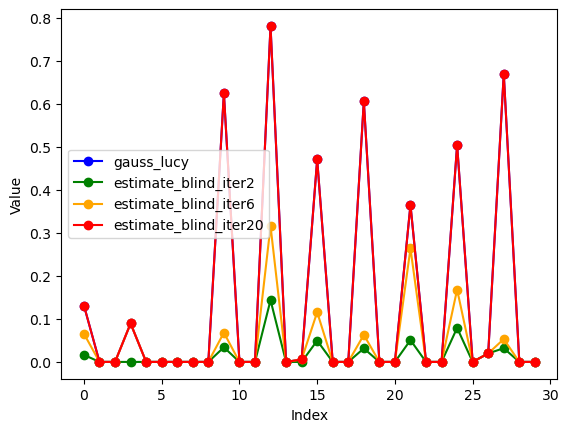

In [ ]:
plt.plot(range(len(flagged2d_gaussian_lucy)), flagged2d_gaussian_lucy, 
         'o-', label='gauss_lucy', color='blue')  # 'o-' means circles with lines

# plt.plot(range(len(flagged2d_estimate_tv)), flagged2d_estimate_tv, 
#          'o-', label='estimate_tv', color='red')  # 'o-' means circles with lines

# plt.plot(range(len(flagged2d_estimate_tv2)), flagged2d_estimate_tv2, 
#          'o-', label='estimate_tv2', color='orange')  # 'o-' means circles with lines

plt.plot(range(len(flagged2d_estimate_blind_iter2)), flagged2d_estimate_blind_iter2, 
         'o-', label='estimate_blind_iter2', color='green')  # 'o-' means circles with lines

plt.plot(range(len(flagged2d_estimate_blind_iter6)), flagged2d_estimate_blind_iter6, 
         'o-', label='estimate_blind_iter6', color='orange')  # 'o-' means circles with lines

plt.plot(range(len(flagged2d_estimate_blind_iter20)), flagged2d_estimate_blind_iter20, 
         'o-', label='estimate_blind_iter20', color='red')  # 'o-' means circles with lines

# plt.plot(range(len(flagged2d_gaussian_tv)), flagged2d_gaussian_tv, 
#          'o-', label='gauss_tv', color='orange')  # 'o-' means circles with lines

# plt.plot(range(len(flagged2d_gibson_tv)), flagged2d_gibson_tv, 
#          'o-', label='gibson_tv', color='cyan') 

# plt.plot(range(len(flagged2d_estimate_tv)), flagged2d_estimate_tv, 
#          'o-', label='estimate_tv', color='green')   





# 
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.show()

#### parallelized version 

In [4]:
print(f'cpus: {os.cpu_count()}')


24

In [4]:

n_jobs = os.cpu_count() - 2
print(f'n_jobs:{n_jobs}')
iterations = [
      #      1,        
            2,
            #3,
            4,
            #5,
            # 6,
            # 7, 
            # 10, 
            # 15,
            # 20,
            #20result[bg].std() / original[bg].std()
            ]

scenes = list(range(len(info.keys())))
# --- Phase 1: load all stacks sequentially (img is stateful) ---
stacks = {}
scene_channels = {}
for scene in scenes:
    img.set_scene(img.scenes[scene])
    channels = list(range(len(info[list(info.keys())[scene]]['image_channels'])))
    scene_channels[scene] = channels
    for channel in channels:
        stacks[(scene, channel)] = img.get_image_data("ZYX", T=0, C=channel)

# --- Phase 2: build flat job list ---
jobs = [
    (stacks[(scene, channel)], scene, channel, num_iter, forced2d)
    for scene in scenes
    for channel in scene_channels[scene]
    for num_iter in iterations
    for forced2d in [True]#[False, True]
]

def run_one(stack, scene, channel, num_iter, forced2d):
    # result, sigma_xy_px = deconvolve(
    #     stack, path_data_all, channel=channel, scene=scene,
    #     num_iter=num_iter, forced2d=forced2d
    # )
    result, sigma_xy_px = deconvolve(
        stack, path_data_all, channel=channel, scene=scene,
        num_iter=num_iter,  psf_model='estimate', forced2d = True, 
        algorithm='blind_richardson_lucy')
    
    flagged = analyze_deconvolution_results(result, stack)
    return (scene, channel, num_iter, forced2d, flagged)

# --- Run in parallel (threading shares imports & sys.path) ---
results = Parallel(n_jobs=n_jobs, backend='threading')(
    delayed(run_one)(*job) for job in jobs
)

# --- Reconstruct flagged lists ---
flagged3d = [r[-1] for r in results if not r[-2]]   # forced2d=False
flagged2d = [r[-1] for r in results if r[-2]]        # forced2d=True


n_jobs:22
0.209 <------------------ pinhole
Applying pinhole factor 0.768 to PSF σ values: σ_xy 3.45 px → 2.65 px, σ_z 2.03 px → 1.56 px
0.18930366492146594 <------------------ pinhole
Applying pinhole factor 0.763 to PSF σ values: σ_xy 3.81 px → 2.90 px, σ_z 2.24 px → 1.71 px
0.16189701492537312 <------------------ pinhole
Applying pinhole factor 0.755 to PSF σ values: σ_xy 4.45 px → 3.36 px, σ_z 2.62 px → 1.98 px
0.16189701492537312 <------------------ pinhole
Applying pinhole factor 0.755 to PSF σ values: σ_xy 4.45 px → 3.36 px, σ_z 2.62 px → 1.98 px
0.16189701492537312 <------------------ pinhole
Applying pinhole factor 0.755 to PSF σ values: σ_xy 4.45 px → 3.36 px, σ_z 2.62 px → 1.98 px
PSF estimate: recovered σ_xy=2.87 px (theoretical estimate was 2.90 px)
PSF (ch2, estimate): λ=573 nm | σ_xy=0.066 µm (2.87 px) | σ_z=0.223 µm (1.71 px) → 2D-per-frame (σ_z=1.71 px, FORCED)
0.16189701492537312 <------------------ pinhole
Applying pinhole factor 0.755 to PSF σ values: σ_xy 4.45 px →


### TRESHOLDING



| Method   |ch0: BRP (puncta)|ch1: HSP70 (diffuse) |ch2: Mitochondria| 
| --       | --              | --                  | --              |
| Otsu     | unstable        | weak performance    | good            |
| Triangle |  **very good**  | mediocre            | good            |
| Yen      | too strict      |often underestimates | ok              |
| Li       | good            |**best of the four** | good            |






In [5]:
#thresholding(date, user, series_list, deconv_iter_list, do_plot = True )
#scenes = list(range(len(info.keys())))

#print(list(range(len(info.keys()))))

series_list = list(range(len(info.keys())))# [0]#
# series_list = [9]
# selected_series = series_list[0]
results_deconv = thresholding(date, user, series_list, [2], channel_struct=2, do_plot = False )

results_deconv_blind_iter2 = thresholding(date, user, series_list, [2], deconv_type='_deconv2d_psfest_blind_iter_', channel_struct =2, do_plot = False )
results_deconv_blind_iter4 = thresholding(date, user, series_list, [4], deconv_type='_deconv2d_psfest_blind_iter_', channel_struct =2, do_plot = False )
# results_deconv_blind_iter6 = thresholding(date, user, series_list, [6], deconv_type='_deconv2d_psfest_blind_iter_', channel_struct =2, do_plot = False )
# results_deconv_blind_iter10 = thresholding(date, user, series_list, [10], deconv_type='_deconv2d_psfest_blind_iter_', channel_struct =2, do_plot = False )
# results_deconv_blind_iter20 = thresholding(date, user, series_list, [20], deconv_type='_deconv2d_psfest_blind_iter_', channel_struct =2, do_plot = False )




[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
/home/gerard/data/confocal/2026_06_05_Carmina/Project.lif
Processing series 0---------------
Channel 0************************
raw ************************
/home/gerard/data/confocal/2026_06_05_Carmina/series_0/channel_0/2026_06_05_s0_ch0.tif
saved /home/gerard/data/confocal/2026_06_05_Carmina/series_0/channel_0/2026_06_05_s0_ch0_masks_95.tif
deconv_iter_2 ************************
/home/gerard/data/confocal/2026_06_05_Carmina/series_0/channel_0/2026_06_05_s0_ch0_deconv2d_iter_2.tif
saved /home/gerard/data/confocal/2026_06_05_Carmina/series_0/channel_0/2026_06_05_s0_ch0_deconv2d_iter_2_masks_95.tif
Channel 1************************
raw ************************
/home/gerard/data/confocal/2026_06_05_Carmina/series_0/channel_1/2026_06_05_s0_ch1.tif
saved /home/gerard/data/confocal/2026_06_05_Carmina/series_0/channel_1/2026_06_05_s0_ch1_masks_95.tif
deconv_iter_2 ************************
/home/gerard/data/confocal/2026_06_05_Carmina/series_0/channel_1/2026_06_

## store results to do not have to run the whole thing again:


In [4]:
path_results = home + date + '_' + user + '/results.pkl' #'/media/data/connectome/KC/some_results/lists_results.pkl'
with open(path_results, 'wb') as f:
    pickle.dump(results, f)

## load the results:

In [5]:
path_results = home + date + '_' + user + '/results.pkl' #'/media/data/connectome/KC/some_results/lists_results.pkl'
#name_lists_results ='/media/data/connectome/KC/some_results/lists_results.pkl'
with open(path_results, 'rb') as f:
    results = pickle.load(f)


In [6]:
print_dict_structure(results)

└─ s_0 (dict):
  └─ c_0 (dict):
    └─ raw (dict):
      └─ stack (ndarray)
      └─ stack_proj (ndarray)
      └─ 95 (dict):
        └─ threshold (float64)
        └─ threshold_proj (float64)
        └─ masks (ndarray)
        └─ mask_proj (ndarray)
    └─ deconv_iter_2 (dict):
      └─ stack (ndarray)
      └─ stack_proj (ndarray)
      └─ 95 (dict):
        └─ threshold (float64)
        └─ threshold_proj (float64)
        └─ masks (ndarray)
        └─ mask_proj (ndarray)
  └─ c_1 (dict):
    └─ raw (dict):
      └─ stack (ndarray)
      └─ stack_proj (ndarray)
      └─ 95 (dict):
        └─ threshold (float64)
        └─ threshold_proj (float64)
        └─ masks (ndarray)
        └─ mask_proj (ndarray)
    └─ deconv_iter_2 (dict):
      └─ stack (ndarray)
      └─ stack_proj (ndarray)
      └─ 95 (dict):
        └─ threshold (float64)
        └─ threshold_proj (float64)
        └─ masks (ndarray)
        └─ mask_proj (ndarray)
  └─ c_2 (dict):
    └─ raw (dict):
      └─ stack (nda

## Understanding the colocalization metrics

To ask whether two proteins occupy the same pixels in the image, we threshold each channel to obtain a binary mask — pixels are either positive (signal present) or negative (signal absent). All three metrics below are computed within a defined region of interest (e.g. the Mushroom Body).

---

### Directional overlap fractions (binary Manders coefficients)

These answer: *of all pixels positive for protein A, what fraction are also positive for protein B?* And vice versa.

- **Fraction of A in B** = |A∩B| / |A| — "what fraction of A pixels have B signal?"
- **Fraction of B in A** = |A∩B| / |B| — "what fraction of B pixels have A signal?"

These are directional: they can be different from each other. For example, if mitochondria are large and HSP70 is a small subset that sits on them, the fraction of HSP in Mito will be high (most HSP is on mitochondria), while the fraction of Mito in HSP will be lower (mitochondria are big, and only part of their surface has HSP).

---

### Enrichment over random

The overlap fractions alone do not tell you whether the co-localization is *more than expected by chance*. If 80% of pixels in a region are Mito-positive and 70% are HSP-positive, you would expect ~56% overlap purely by random spatial overlap, regardless of any physical association.

The enrichment corrects for this:

**Enrichment = observed overlap / expected random overlap**

where the expected overlap is calculated assuming the two signals are distributed independently within the region. An enrichment of 1.0 means no association beyond chance; an enrichment of 6× means the two proteins co-localize six times more than would be predicted if they were independently distributed.

---

### Odds ratio

The odds ratio (OR) is the most statistically rigorous of the three. It asks: *how much more likely is a pixel to be B-positive if it is A-positive, compared to if it is A-negative?*

- **OR = 1**: knowing a pixel is A-positive gives no information about B — the two signals are independent
- **OR > 1**: A-positive pixels are more likely to carry B signal — positive co-localization
- **OR = 52**: an A-positive pixel is 52 times more likely to also be B-positive than an A-negative pixel

The OR is accompanied by a p-value. With microscopy images (thousands of pixels), p-values are almost always effectively zero — what matters is the **size of the OR**, not whether p < 0.05. An OR of 2 is meaningful; an OR of 900 is dramatic.

---

### Using the three metrics together

| Metric | What it tells you |
|---|---|
| Fraction A in B | How much of A is "covered" by B |
| Fraction B in A | How much of B is "covered" by A |
| Enrichment | Is co-localization above what chance would produce? |
| Odds ratio | How strongly are A and B spatially associated? |

A complete interpretation uses all three: the fractions describe the *extent* of overlap, the enrichment shows whether it is *above chance*, and the odds ratio quantifies the *strength of association* independently of how prevalent each signal is.


In [7]:
names_list = list(info.keys())

In [8]:
df_deconv = compute_colocalization(results_deconv, series_list, names_list, raw=False, deconv_iter=2, export=False)
df_raw = compute_colocalization(results_deconv, series_list, names_list, raw=True, deconv_iter=2, export=False)
df_deconv_blind2 = compute_colocalization(results_deconv_blind_iter2, series_list, names_list, raw=False, deconv_iter=2, export=False)
df_deconv_blind4 = compute_colocalization(results_deconv_blind_iter4, series_list, names_list, raw=False, deconv_iter=4, export=False)
# df_deconv_blind6 = compute_colocalization(results_deconv_blind_iter6, series_list, names_list, raw=False, deconv_iter=6, export=False)
# df_deconv_blind10 = compute_colocalization(results_deconv_blind_iter10, series_list, names_list, raw=False, deconv_iter=10, export=False)
# df_deconv_blind20 = compute_colocalization(results_deconv_blind_iter20, series_list, names_list, raw=False, deconv_iter=20, export=False)




Spearman(snr_min_HSP_Mito, MB_total_odds_ratio) = 0.648 (p=0.043)
Spearman(snr_min_HSP_Mito, MB_total_enrichment) = 0.648 (p=0.043)
Spearman(snr_min_HSP_Mito, MB_total_odds_ratio) = -0.612 (p=0.060)
Spearman(snr_min_HSP_Mito, MB_total_enrichment) = -0.596 (p=0.069)
Spearman(snr_min_HSP_Mito, MB_total_odds_ratio) = -0.559 (p=0.093)
Spearman(snr_min_HSP_Mito, MB_total_enrichment) = -0.492 (p=0.148)
Spearman(snr_min_HSP_Mito, MB_total_odds_ratio) = -0.418 (p=0.229)
Spearman(snr_min_HSP_Mito, MB_total_enrichment) = -0.418 (p=0.229)


group: deconv, mean: 0.25830000000000003, sem: 0.048874908354560286
group: raw, mean: 0.1085, sem: 0.011290359702959963
group: blind2, mean: 0.11120000000000001, sem: 0.01082774214691133
group: blind4, mean: 0.11040000000000001, sem: 0.010486181383134662


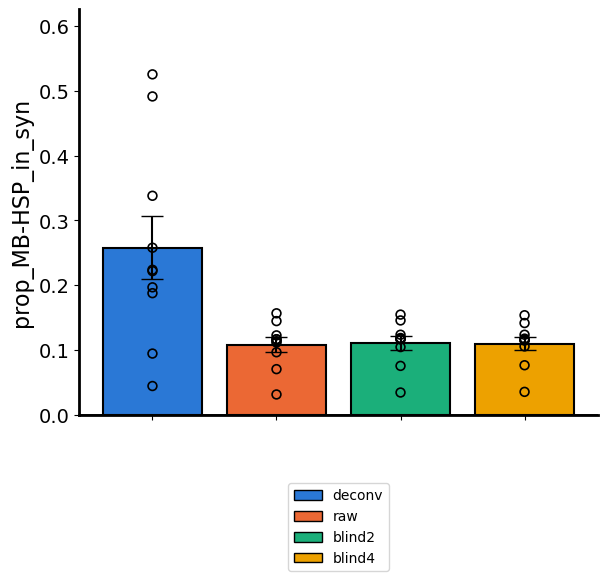

group: deconv, mean: 0.2375, sem: 0.055982189628091136
group: raw, mean: 0.1129, sem: 0.011891593669479292
group: blind2, mean: 0.1149, sem: 0.011594491029028493
group: blind4, mean: 0.1133, sem: 0.0112339267894673


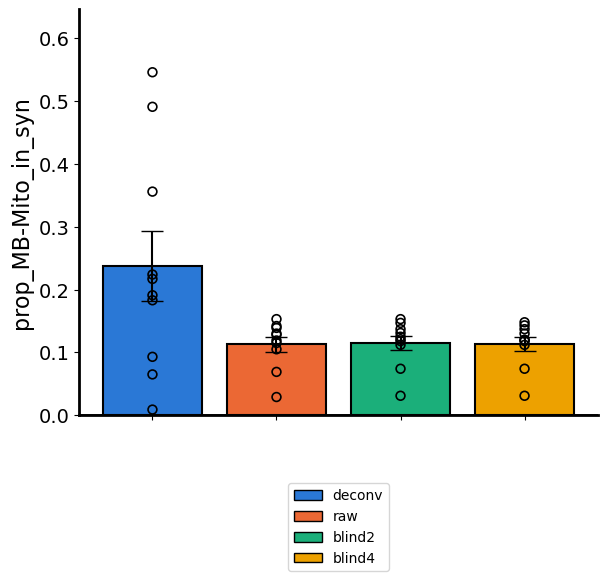

group: deconv, mean: 0.4091, sem: 0.06597347109929026
group: raw, mean: 0.13290000000000002, sem: 0.012265081419306689
group: blind2, mean: 0.1358, sem: 0.013895482879138978
group: blind4, mean: 0.13879999999999998, sem: 0.01315362223031275


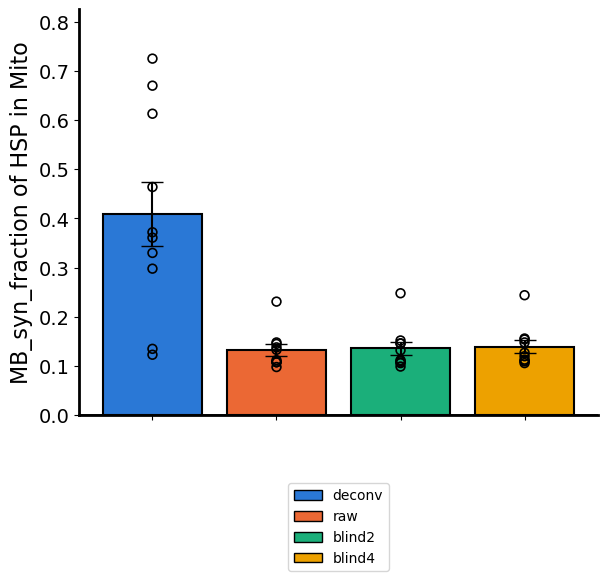

In [13]:
categorical_colors = [
    '#2a78d6',  # blue
    '#eb6834',  # orange
    '#1baf7a',  # aqua
    '#eda100',  # yellow
    '#e87ba4',  # magenta
    '#008300',  # green
    '#4a3aa7',  # violet
    '#e34948',  # red
]


column_list = ['prop_MB-HSP_in_syn', 'prop_MB-Mito_in_syn', 'MB_syn_fraction of HSP in Mito']
rows2include = []

dfs = {
    'deconv': df_deconv,
    'raw': df_raw,
    'blind2': df_deconv_blind2,
    'blind4': df_deconv_blind4,
    # 'blind6': df_deconv_blind6,
    # 'blind10': df_deconv_blind10,
    # 'blind20': df_deconv_blind20,
}

for col in column_list:
    new_df = pd.DataFrame()
    new_df_dict = {}
    for df_k in dfs.keys():
        new_df_dict[df_k] = dfs[df_k][col]

    new_df = pd.concat(new_df_dict, axis=1)
    #new_df = new_df.iloc[0:8] 
    
    #print(new_df.head())
    fast_plotter(list(dfs.keys()), df= new_df, ylabel=col, bar_color=categorical_colors[:len(list(dfs.keys()))],  quietStats=True, figsize=(6,6), legend=True)

    



In [11]:
def df_separator(df):
    # 5x vs 1x
    keys = ['5x', '1x', '5x.alpha_', '5x.alphaprime_','5x.gamma_', '1x.alpha_', '1x.alphaprime_','1x.gamma_']
    dict_results = dict.fromkeys(keys) 
    for k in keys:
        ks = k.split('.')
        if len(ks) == 1:
            dict_results[k] = df[df['name'].str.contains(k, case=False, na=False)]
        else:
            dict_results[k] = df[
                            df['name'].str.contains(ks[0], case=False, na=False) &
                            df['name'].str.contains(ks[1], case=False, na=False)
                                                    ]
    return(dict_results)


    # df_5x =df[df['name'].str.contains('5x', case=False, na=False)]
    # df_1x = df[df['name'].str.contains('1x', case=False, na=False)]






===== df_list[0] — 5x only (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x
  W statistic = 0.7672
  p-value     = 0.0058
  → Significant deviation from normality

MB_non_syn_fraction of HSP in Mito_5x
  W statistic = 0.8276
  p-value     = 0.0313
  → Significant deviation from normality

Brown-Forsythe test
Statistic = 2.3861
p-value   = 0.1398
→ Variances are not significantly different

group: MB_syn_fraction of HSP in Mito_5x, mean: 0.13290000000000002, sem: 0.012265081419306689
group: MB_non_syn_fraction of HSP in Mito_5x, mean: 0.11380000000000001, sem: 0.004758150901348127


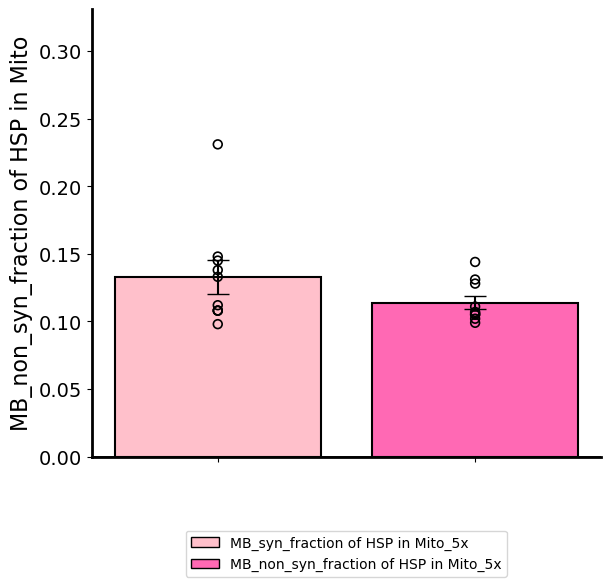


===== df_list[0] — 5x only by subregion =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x.alpha_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_5x.alpha_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_5x.alphaprime_
  W statistic = 0.8929
  p-value     = 0.3966
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.alphaprime_
  W statistic = 0.9486
  p-value     = 0.7073
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.8953
  p-value     = 0.4083
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.9447
  p-value     = 0.6830
  → Data look approximately normal

Brown-Forsythe test
Statistic = 1.2612
p-value   = 0.3338
→ Variances are not significantly different

One-way ANOVA
F statistic = 2.0450
p-value     = 0.1340
→ No significant differences detected


Effect size
E

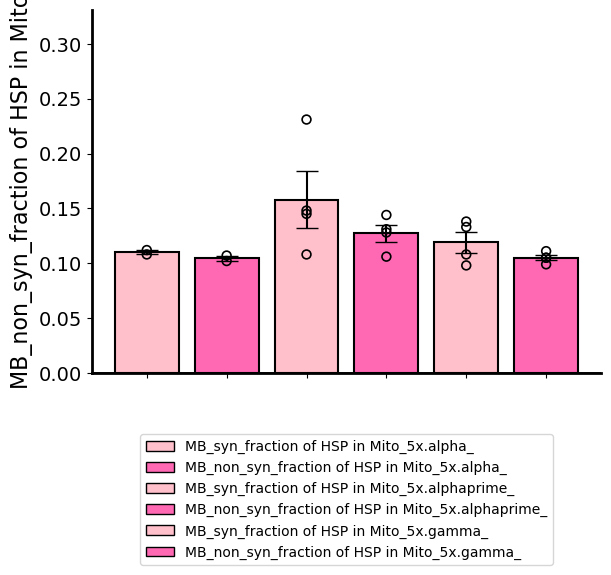


===== df_list[1] — 5x only (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x
  W statistic = 0.9368
  p-value     = 0.5184
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x
  W statistic = 0.9481
  p-value     = 0.6457
  → Data look approximately normal

Brown-Forsythe test
Statistic = 7.9460
p-value   = 0.0114
→ Variances differ significantly

group: MB_syn_fraction of HSP in Mito_5x, mean: 0.4091, sem: 0.06597347109929026
group: MB_non_syn_fraction of HSP in Mito_5x, mean: 0.2884, sem: 0.01613636335182814


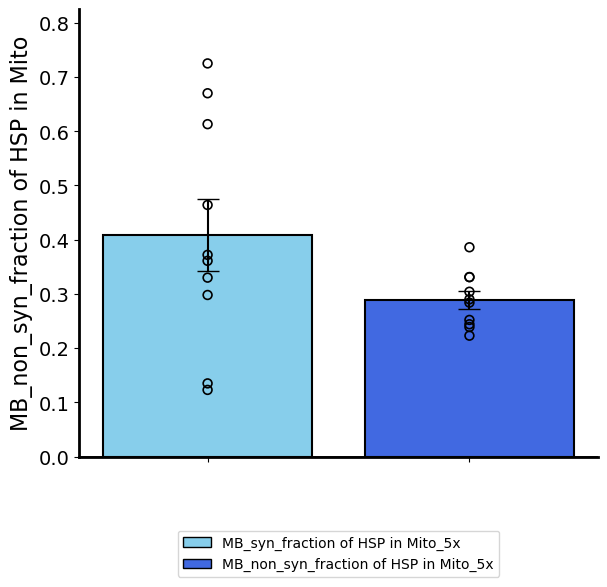


===== df_list[1] — 5x only by subregion =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x.alpha_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_5x.alpha_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_5x.alphaprime_
  W statistic = 0.9078
  p-value     = 0.4707
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.alphaprime_
  W statistic = 0.9772
  p-value     = 0.8857
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.7847
  p-value     = 0.0774
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.9215
  p-value     = 0.5456
  → Data look approximately normal

Brown-Forsythe test
Statistic = 8.3561
p-value   = 0.0008
→ Variances differ significantly

group: MB_syn_fraction of HSP in Mito_5x.alpha_, mean: 0.351, sem: 0.02099999999999999
group: MB_non_syn_fraction of HSP

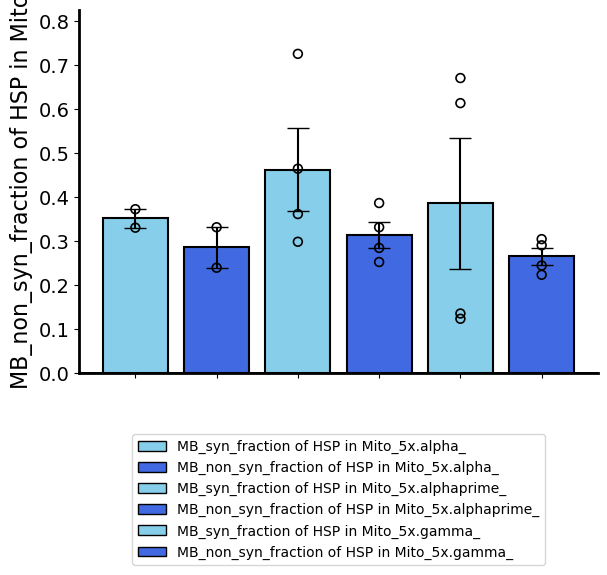


===== df_list[2] — 5x only (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x
  W statistic = 0.7505
  p-value     = 0.0036
  → Significant deviation from normality

MB_non_syn_fraction of HSP in Mito_5x
  W statistic = 0.8827
  p-value     = 0.1400
  → Data look approximately normal

Brown-Forsythe test
Statistic = 1.9172
p-value   = 0.1831
→ Variances are not significantly different

group: MB_syn_fraction of HSP in Mito_5x, mean: 0.1358, sem: 0.013895482879138978
group: MB_non_syn_fraction of HSP in Mito_5x, mean: 0.1169, sem: 0.005445589448759835


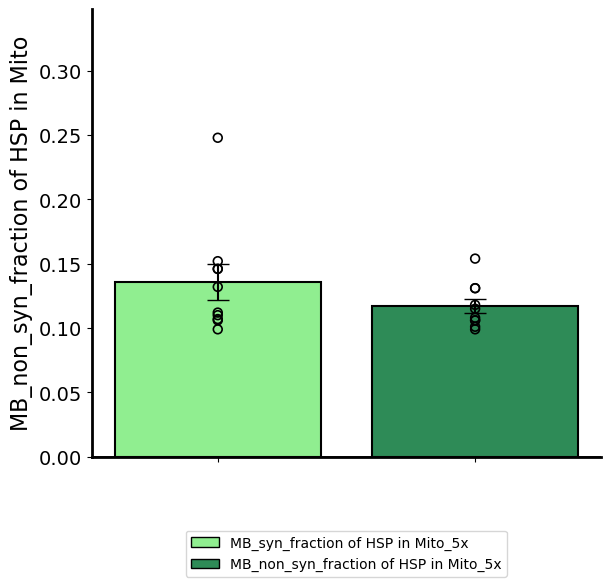


===== df_list[2] — 5x only by subregion =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x.alpha_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_5x.alpha_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_5x.alphaprime_
  W statistic = 0.8625
  p-value     = 0.2691
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.alphaprime_
  W statistic = 0.9438
  p-value     = 0.6779
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.9640
  p-value     = 0.8041
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.9452
  p-value     = 0.6864
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.9554
p-value   = 0.4768
→ Variances are not significantly different

One-way ANOVA
F statistic = 1.5350
p-value     = 0.2418
→ No significant differences detected


Effect size
E

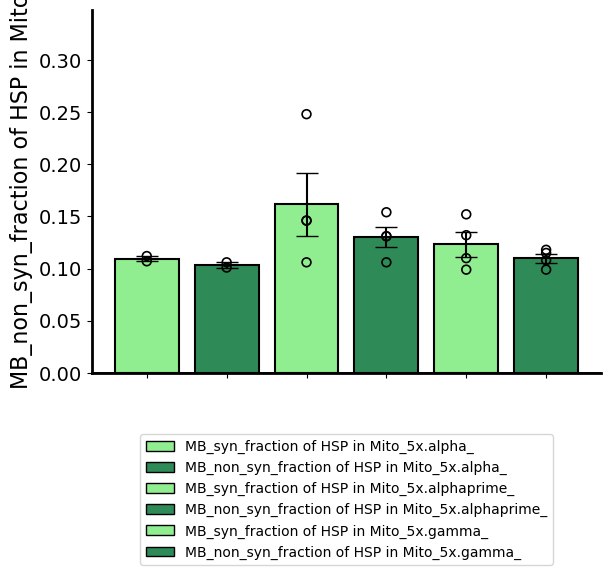


===== df_list[3] — 5x only (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x
  W statistic = 0.7534
  p-value     = 0.0039
  → Significant deviation from normality

MB_non_syn_fraction of HSP in Mito_5x
  W statistic = 0.9346
  p-value     = 0.4949
  → Data look approximately normal

Brown-Forsythe test
Statistic = 1.5075
p-value   = 0.2353
→ Variances are not significantly different

group: MB_syn_fraction of HSP in Mito_5x, mean: 0.13879999999999998, sem: 0.01315362223031275
group: MB_non_syn_fraction of HSP in Mito_5x, mean: 0.11960000000000001, sem: 0.005572152985057831


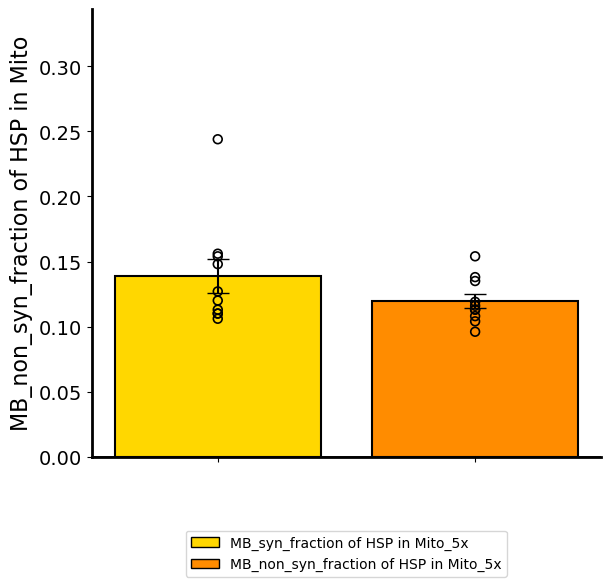


===== df_list[3] — 5x only by subregion =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x.alpha_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_5x.alpha_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_5x.alphaprime_
  W statistic = 0.9026
  p-value     = 0.4443
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.alphaprime_
  W statistic = 0.9437
  p-value     = 0.6772
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.9142
  p-value     = 0.5047
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.8477
  p-value     = 0.2188
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.9863
p-value   = 0.4602
→ Variances are not significantly different

One-way ANOVA
F statistic = 1.8972
p-value     = 0.1587
→ No significant differences detected


Effect size
E

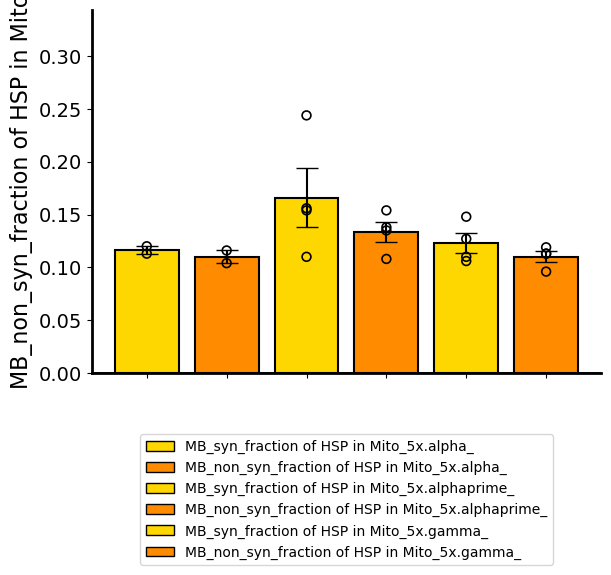

In [12]:

colmns2plot = ['MB_syn_fraction of HSP in Mito','MB_non_syn_fraction of HSP in Mito']
#colmns2plot = ['prop_MB-HSP_in_syn']
df_list = [
        df_raw,
        df_deconv,
        df_deconv_blind2, 
        df_deconv_blind4,
        # df_deconv_blind10, 
        # df_deconv_blind20,
                
         ]
colors = [["pink","hotpink"],["skyblue","royalblue"],["lightgreen","seagreen"],["gold","darkorange"]]


# '5x'/'1x' are pooled totals; the six '.'-keys are per-subregion breakdowns of the
# SAME rows (e.g. '5x.alpha_' rows are a subset of '5x' rows). Mixing pooled and
# subregion groups in one fast_plotter call would run ANOVA/Tukey on non-independent
# groups, so each combination below is plotted separately.
plot_configs = [
   # ("5x vs 1x (pooled, all regions combined)", ['5x', '1x']),
    #("5x vs 1x by subregion", ['5x.alpha_', '5x.alphaprime_', '5x.gamma_',
    #                            '1x.alpha_', '1x.alphaprime_', '1x.gamma_']),
    ("5x only (pooled, all regions combined)", ['5x']),
   # ("1x only (pooled, all regions combined)", ['1x']),
    ("5x only by subregion", ['5x.alpha_', '5x.alphaprime_', '5x.gamma_']),
    #("1x only by subregion", ['1x.alpha_', '1x.alphaprime_', '1x.gamma_']),
]

for j,df in enumerate(df_list):
    df_dict = df_separator(df)

    for title, key_group in plot_configs:
        col_data = {}
        new_col_list = []
        for k in key_group:
            df_k = df_dict[k]
            for col in colmns2plot:
                new_col = f"{col}_{k}"
                new_col_list.append(new_col)
                # reset_index: each key's rows keep their original df index (disjoint
                # across keys), so assigning straight into a DataFrame would align on
                # that index and turn every group but the first into all-NaN columns.
                col_data[new_col] = df_k[col].reset_index(drop=True)
        all_df = pd.concat(col_data, axis=1)

        print(f"\n===== df_list[{j}] — {title} =====")

        # one color per column-type in colmns2plot, repeated once per key in key_group
        # (works for any combination of len(colmns2plot)/len(key_group), unlike a
        # fixed /2 divisor which breaks when colmns2plot has an odd length or 1 entry)
        bar_color = colors[j][:len(colmns2plot)] * len(key_group)
        fast_plotter(new_col_list, df= all_df, ylabel=col,  bar_color=bar_color,  quietStats=False, figsize=(6,6), legend=True)


## Is the SNR-vs-colocalization correlation biology or a noise artifact? A calibration check

The Spearman correlation above shows SNR and odds ratio moving together, but that pattern is also exactly what **pure noise-driven attenuation toward the null** predicts, with zero real biological difference between brains (non-differential misclassification of both channel masks biases odds ratio/enrichment toward 1 as noise increases).

To get a noise-only reference, we take the sample with the best HSP/Mito SNR (the one we trust most), and progressively add synthetic Gaussian noise to its two channels, recomputing the same 95th-percentile mask -> odds ratio/enrichment pipeline at each noise level. Because the underlying true image never changes, any change across noise levels is coming from noise alone — this is what "colocalization" would look like if the true biology were held constant and only measurement noise varied.

We then interpolate each real brain's own SNR onto this noise-only curve to get `MB_total_odds_ratio_noise_null`: the odds ratio expected at that brain's SNR if it had the reference brain's true biology and its lower measured value were pure artifact. The ratio of the actual measured value to this expectation (`MB_total_odds_ratio_excess_ratio`):
- **~1** — fully consistent with noise-only attenuation; no evidence this brain differs biologically from the reference.
- **> 1** — more colocalization than noise alone would produce at that SNR — evidence of a real signal beyond the artifact.
- **< 1** — less colocalization than even pure noise would give — worth a closer look (could be a genuine biological difference, or an unrelated problem with that sample).

**Caveat:** this assumes every brain's true biology matches the reference brain and that lower-SNR brains are just "reference + more noise." That's a strong simplification (real brains differ in more than noise), so treat this as a lower bound / sanity check on how much noise alone can distort the metric, not a hard correction.

In [9]:
np.random.seed(0)

def add_gaussian_noise(stack, sigma):
    if sigma == 0:
        return stack.astype(np.float32)
    return stack.astype(np.float32) + np.random.normal(0, sigma, size=stack.shape).astype(np.float32)

def coloc_stats(stack_A, stack_B, MASK, percentile=95):
    """Same odds-ratio/enrichment formulas as the main coloc cell, computed directly from raw stacks."""
    mask_A = (stack_A > np.percentile(stack_A, percentile)) & MASK
    mask_B = (stack_B > np.percentile(stack_B, percentile)) & MASK

    A_and_B = (mask_A & mask_B).sum()
    A_not_B = (mask_A & ~mask_B).sum()
    B_not_A = (~mask_A & mask_B).sum()
    neither = MASK.sum() - A_and_B - A_not_B - B_not_A

    odds_ratio, _ = fisher_exact([[A_and_B, A_not_B], [B_not_A, neither]], alternative='greater')

    pA = mask_A.sum() / MASK.sum()
    pB = mask_B.sum() / MASK.sum()
    expected = pA * pB * MASK.sum()
    enrichment = A_and_B / expected

    return odds_ratio, enrichment

# --- reference sample: the one with the best HSP/Mito SNR already in df ---
ref_name = df.sort_values('snr_min_HSP_Mito', ascending=False)['name'].iloc[0]
ref_series = series_list[list(info.keys()).index(ref_name)]
print(f'Calibrating on reference sample: {ref_name} (series {ref_series})')

ref_HSP  = results['s_' + str(ref_series)]['c_1'][deconv_str_mask]['stack'].astype(np.float32)
ref_Mito = results['s_' + str(ref_series)]['c_2'][deconv_str_mask]['stack'].astype(np.float32)
ref_MB   = results['s_' + str(ref_series)]['c_2'][deconv_str_mask]['mb'].astype(bool)

sigma0_HSP  = ref_HSP[ref_HSP <= np.median(ref_HSP)].std()
sigma0_Mito = ref_Mito[ref_Mito <= np.median(ref_Mito)].std()

# multiples of each channel's own background std, spanning down to the noisiest real sample's SNR
noise_levels = [0, 0.5, 1, 2, 3, 4, 6, 8, 12, 16, 24]

calib_rows = []
for k in noise_levels:
    noisy_HSP  = add_gaussian_noise(ref_HSP,  k * sigma0_HSP)
    noisy_Mito = add_gaussian_noise(ref_Mito, k * sigma0_Mito)

    snr_min_k = min(snr_proxy(noisy_HSP), snr_proxy(noisy_Mito))
    OR_k, enrich_k = coloc_stats(noisy_HSP, noisy_Mito, ref_MB)

    calib_rows.append({'noise_k': k, 'snr_min': snr_min_k, 'odds_ratio': OR_k, 'enrichment': enrich_k})

df_calib = pd.DataFrame(calib_rows).sort_values('snr_min').reset_index(drop=True)
print(df_calib)

# --- interpolate the noise-only curve onto each real sample's actual SNR ---
df['MB_total_odds_ratio_noise_null']   = np.interp(df['snr_min_HSP_Mito'], df_calib['snr_min'], df_calib['odds_ratio'])
df['MB_total_enrichment_noise_null']   = np.interp(df['snr_min_HSP_Mito'], df_calib['snr_min'], df_calib['enrichment'])
df['MB_total_odds_ratio_excess_ratio'] = df['MB_total_odds_ratio'] / df['MB_total_odds_ratio_noise_null']

df.to_csv(path_csv, index=False)
df[['name', 'snr_min_HSP_Mito', 'MB_total_odds_ratio', 'MB_total_odds_ratio_noise_null',
    'MB_total_odds_ratio_excess_ratio']].sort_values('snr_min_HSP_Mito', ascending=False)


Calibrating on reference sample: dec02_5x_brain1gamma_L (series 1)
    noise_k  snr_min  odds_ratio  enrichment
0      24.0    2.733    1.094775    1.080853
1      16.0    2.737    1.206465    1.168631
2      12.0    2.747    1.354346    1.274477
3       8.0    2.784    1.717142    1.493750
4       6.0    2.847    2.125943    1.691276
5       4.0    3.024    3.001190    2.012805
6       3.0    3.253    3.804066    2.230852
7       2.0    3.741    4.982020    2.473443
8       1.0    4.714    6.454261    2.709873
9       0.5    5.291    7.016664    2.787834
10      0.0    5.564    7.238342    2.817133


,name,snr_min_HSP_Mito,MB_total_odds_ratio,MB_total_odds_ratio_noise_null,MB_total_odds_ratio_excess_ratio
1,dec02_5x_brain1gamma_L,5.564,7.238,7.238342,0.999953
0,dec02_5x_brain1alphaprime_L,4.641,9.247,6.343805,1.457643
2,dec02_5x_brain1gamma_R,4.296,5.239,5.821787,0.899895
7,dec02_5x_brain3gamma_L,4.091,1.840,5.511603,0.333841
4,dec02_5x_brain2gamma_L,3.998,2.198,5.370885,0.409244
8,dec02_5x_brain3alphaprime_R,3.926,3.512,5.261942,0.667434
9,dec02_5x_brain3alpha_R,3.779,3.184,5.039517,0.631807
5,dec02_5x_brain3alphaprime_L,3.184,2.532,3.562151,0.710806
6,dec02_5x_brain3alpha_L,3.090,2.059,3.232586,0.636951
3,dec02_5x_brain2alphaprime_L,3.056,2.102,3.113382,0.675150
